In [19]:
import pandas as pd
from matplotlib.pyplot import *
from scipy import stats
import seaborn as sns

In [20]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [21]:
#summary = pd.read_csv('stan/outputs/summaries/results_20250804142343.csv', index_col=0)
#summary = pd.read_csv('stan/outputs/summaries_30/results_20250804212421.csv', index_col=0) # prior on m_0 -> 30
summary = pd.read_csv('stan/outputs/summaries_30/results_20250804214456.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-27502.600000,1.553250,65.482400,-27610.900000,-27503.100000,-27394.500000,1777.33,2.89373,1.002980
z_m_0_15[1],0.038025,0.000224,0.007302,0.026279,0.037990,0.050348,1058.42,1.72325,1.004870
z_m_0_15[2],0.033391,0.000191,0.007447,0.021118,0.033434,0.045663,1515.81,2.46794,1.008510
z_m_0_15[3],0.038897,0.000159,0.007583,0.026591,0.038701,0.051554,2270.41,3.69654,1.004090
z_m_0_15[4],0.033817,0.000169,0.007550,0.021277,0.033901,0.046068,2000.22,3.25662,1.003900
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.509792,0.001227,0.151761,0.262220,0.509901,0.755858,15309.80,24.92640,0.999564
delta_avg_log_var_s_1322[36],0.622319,0.001189,0.153278,0.368677,0.622287,0.873267,16617.80,27.05610,0.999763
delta_avg_log_var_s_1322[37],0.730331,0.001286,0.159401,0.465897,0.731238,0.994032,15356.20,25.00190,0.999431
delta_avg_log_var_s_1322[38],0.492202,0.001201,0.156377,0.236271,0.492730,0.752068,16953.70,27.60280,0.999670


In [22]:
zs = []
for x in summary.index:
    ys = x.split('[')
    if len(ys) == 1:
        zs.append(ys[0])
    else:
        ts = ys[1].split(',')
        if len(ts) == 1:
            zs.append(ys[0] + '[i]')
        else:
            zs.append(ys[0] + '[i,j]')
zs = set(zs)
zs

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_s_15_1223[i]',
 'avg_sigma_s_15_1322[i]',
 'avg_sigma_s_30[i]',
 'avg_sigma_s_30_1124[i]',
 'avg_sigma_s_30_1223[i]',
 'avg_sigma_s_30_1322[i]',
 'avg_sigma_s_30_narrowrange[i]',
 

In [23]:
summary.loc[['sqrt_mse_15[10]', 'log_var_0_15[1]', 'sigma_0_15[10]', 'var_0_15[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
sqrt_mse_15[10],2.07724,0.001366,0.103234,1.913120,2.074730,2.253580,5714.77,9.30441,1.00047
log_var_0_15[1],0.66075,0.001393,0.101022,0.495621,0.661305,0.825713,5258.28,8.56118,1.00055
sigma_0_15[10],2.06255,0.001342,0.101933,1.899740,2.059940,2.236500,5770.30,9.39483,1.00059
var_0_15[10],4.26449,0.005558,0.422723,3.609020,4.243330,5.001920,5783.74,9.41671,1.00058


In [24]:
summary.loc[['tau', 'nu']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,1.30472,0.00073,0.03761,1.24341,1.30383,1.36754,2690.12000,4.37988,1.00309
nu,0.22874,0.00014,0.00860,0.21463,0.22877,0.24292,3852.58381,6.27252,1.00241


In [25]:
( summary.R_hat > 1.01 ).mean()

0.0

In [26]:
summary[summary.R_hat>1.01]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat


In [27]:
summary.loc[[f'sigma_0_15[{i}]' for i in range(1,17)] ] #
#summary.loc[['sigma_0_15', 'sigma_0_30'] ] #

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
sigma_0_15[1],1.39327,0.000967,0.070394,1.28122,1.39188,1.51113,5294.46,8.62009,1.000560
sigma_0_15[2],1.69745,0.001090,0.081813,1.56395,1.69657,1.83451,5632.06,9.16976,1.000520
sigma_0_15[3],2.02595,0.001237,0.098272,1.86904,2.02317,2.19231,6311.90,10.27660,1.001070
sigma_0_15[4],1.93003,0.001192,0.093486,1.78339,1.92770,2.08657,6145.81,10.00620,1.000660
sigma_0_15[5],1.95928,0.001227,0.097332,1.80531,1.95610,2.12533,6293.64,10.24690,0.999692
sigma_0_15[6],2.08339,0.001317,0.100290,1.92485,2.07957,2.25512,5802.23,9.44681,1.000860
sigma_0_15[7],2.04147,0.001285,0.097804,1.88306,2.03842,2.20882,5790.89,9.42835,1.000990
sigma_0_15[8],2.00969,0.001294,0.098173,1.85062,2.00783,2.17341,5754.97,9.36986,1.000220
sigma_0_15[9],2.04161,0.001297,0.100370,1.88100,2.03885,2.21094,5990.04,9.75259,0.999943
sigma_0_15[10],2.06255,0.001342,0.101933,1.89974,2.05994,2.23650,5770.30,9.39483,1.000590


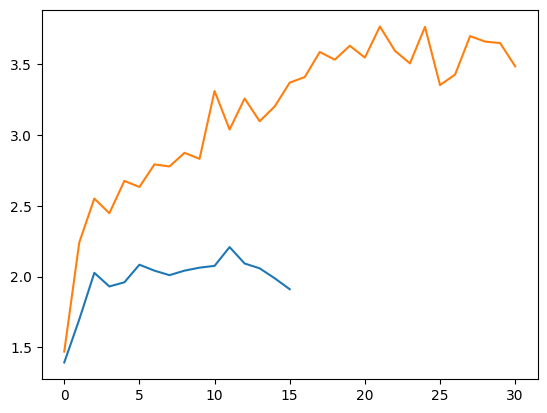

In [28]:
plot( summary.loc[[f'sigma_0_15[{i}]' for i in range(1,16+1)] ].Mean.values )
plot( summary.loc[[f'sigma_0_30[{i}]' for i in range(1,31+1)] ].Mean.values )

In [29]:
summary.loc[[f'sigma_s_15[{sid},{i}]' for i in range(1,17) for sid in range(1,40)] ]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
"sigma_s_15[1,1]",2.06301,0.002078,0.251589,1.695900,2.04075,2.51941,14655.8,23.8616,0.999429
"sigma_s_15[2,1]",2.40374,0.002531,0.315867,1.945620,2.37359,2.96599,15573.1,25.3550,0.999539
"sigma_s_15[3,1]",1.84672,0.002280,0.263227,1.467450,1.82083,2.32262,13326.7,21.6977,0.999510
"sigma_s_15[4,1]",2.59456,0.002553,0.334242,2.108280,2.56271,3.19005,17142.0,27.9094,0.999577
"sigma_s_15[5,1]",1.12599,0.001166,0.151155,0.900979,1.11221,1.39579,16806.9,27.3639,0.999688
...,...,...,...,...,...,...,...,...,...
"sigma_s_15[35,16]",1.85748,0.002172,0.270775,1.464510,1.83268,2.34225,15542.4,25.3051,1.000010
"sigma_s_15[36,16]",1.63084,0.002176,0.267141,1.241500,1.60365,2.10535,15073.8,24.5422,0.999517
"sigma_s_15[37,16]",1.74207,0.002300,0.280078,1.340200,1.71091,2.24539,14825.9,24.1385,0.999751
"sigma_s_15[38,16]",1.85725,0.002598,0.304799,1.421370,1.82221,2.41037,13761.3,22.4052,0.999481


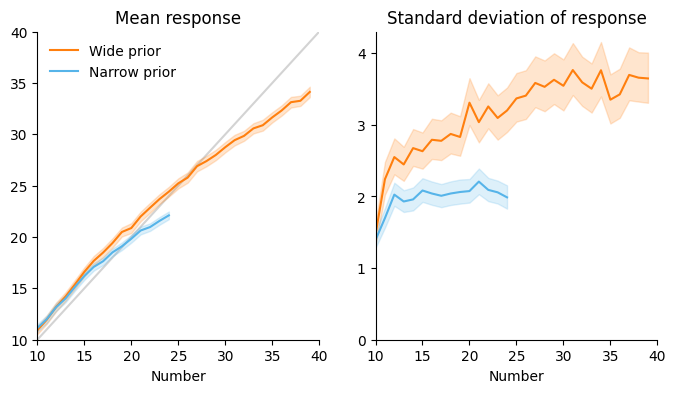

In [47]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize() + ' prior')
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                # p_pos = summary.loc[f'bin_avg_sqrt_mse_diff_pos[{i+1}]']['Mean'].squeeze()
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

In [31]:
np.arange(10, 10+W_NARROW+1)

array([10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22.,
       23., 24., 25.])

In [32]:
def norm(x, mu, w):
    return np.exp(-.5*((x-mu)/w)**2)

def prf(x, mu, w):
    return norm( np.log(x), np.log(mu), w )


In [33]:
def plot_prior(ax, x0, x1, v, c, zorder=None, ylabel='Probability'):
    ax.plot([x0,x1], [v, v], c=c, zorder=zorder)
    ax.plot([x0,x0], [0, v], c=c, ls=':', zorder=zorder)
    ax.plot([x1,x1], [0, v], c=c, ls=':', zorder=zorder)
    if ylabel:
        ax.set_ylabel(ylabel)

In [34]:
from matplotlib.patches import ConnectionPatch

7 10 13 16 19 22 25 

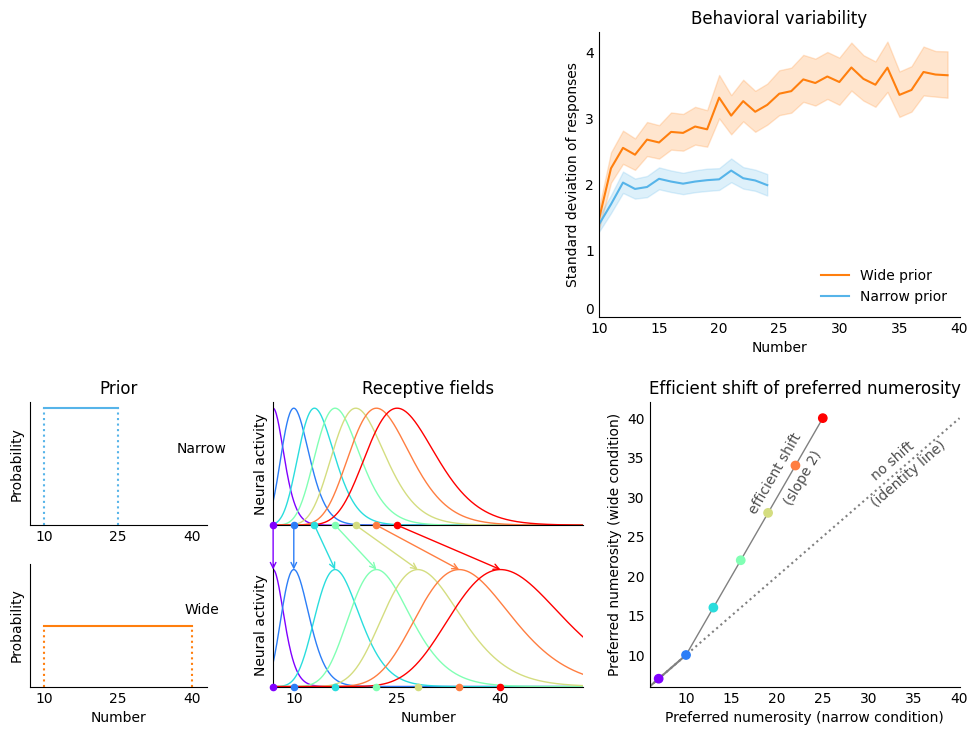

In [57]:
fig, axs = subplots(nrows=3, ncols=3, figsize=(12,8.5), width_ratios=[8,14,14], height_ratios=[2.7,1,1])

gs = axs[0, 0].get_gridspec()
for ax in axs[1:, 2]:
    ax.remove()
axbig = fig.add_subplot(gs[1:, 2])
axs[0,0].remove()
axs[0,1].remove()

axPriorN = axs[1,0]
axPriorW = axs[2,0]
axRF_N = axs[1,1]
axRF_W = axs[2,1]

#axStdDev = axs[0,2]
axs[0,2].remove()
gs_top = GridSpec(nrows=2, ncols=10, hspace=.3)
axStdDev = fig.add_subplot(gs_top[0, 6:])
#axStdDev = fig.add_subplot( 2, 2, 2 )

#### Std Dev subjects
plot_subjects_stan(ax_m=None, ax_sigma=axStdDev)
#axs[0].legend(loc='upper left')
#axs[0].set_title('Mean response')
axStdDev.set_title('Behavioral variability')
axStdDev.set_xlim(10,40)
axStdDev.set_ylim(0,None)
axStdDev.set_yticks([0,1,2,3,4])
axStdDev.set_xlabel('Number') # $x$
axStdDev.set_ylabel('Standard deviation of responses') # $\hat x$
axStdDev.legend(loc='lower right', )
axStdDev.get_yticklabels()[0].set_verticalalignment('bottom')
#####

sigma = .2
xx = np.linspace(5, 56, 500)
no_change = False
pref_nums = np.arange(7, 26, 3)
num_tcs = len(pref_nums)
cmap = cm.rainbow

### priors
plot_prior(axPriorN, 10, 25, 1./16, c=COLORS_COND[NARROW])
plot_prior(axPriorW, 10, 40, 1./31, c=COLORS_COND[WIDE])
axPriorW.set_ylim( *axPriorN.get_ylim() )
axPriorW.set_xlabel('Number')
axPriorN.set_title('Prior')
axPriorN.text(42,1.2/31,'Narrow', ma='center', ha='center')
axPriorW.text(42,1.2/31,'Wide', ma='center', ha='center')
for ax in axs[1:,0]: ax.set_xlim(7,43)

### receptive fields
pref_nums_w = []
for ii,mode in enumerate( pref_nums ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs[1:,:2].flatten():
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs[1:,1]: ax.set_xlim(7,52)

#for pref_n in [10, 15, 20, 25]:
#for pref_n in pref_nums[1:]:
for pref_n in pref_nums[:]:
    print(pref_n, end=' ')
    pref_w = pref_n if no_change or pref_n <= 10 else ( 10 + 2*(pref_n-10) )
    c = cmap( (pref_n-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) )
    con = ConnectionPatch(xyA=(pref_n, 0), xyB=(pref_w, prf(pref_w,pref_w,sigma)), coordsA='data', coordsB='data',
            axesA=axRF_N, axesB=axRF_W, color=c, arrowstyle='->', linewidth=1, zorder=100)
    axRF_W.add_artist(con)

axbig.scatter(pref_nums, pref_nums_w, c=cmap( (pref_nums-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ), zorder=1000, clip_on=False)
axbig.plot([5,10], [5,10], c='grey')
axbig.axline([10,10], slope=1, ls=':', c='grey')
axbig.set_xlim(6, 40) # 28)
axbig.plot([10,25],[10,40], c='grey', lw=1)
#axbig.text(29.25, 29.8, 'no adaptation\n(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 30+2.15, 'no shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 28.8, '(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
# axbig.annotate('efficient adaptation\n(slope = 2)', xy=(20,30), xytext=(15, 35), c=(.2,)*3, ma='center', ha='center',
#                arrowprops=dict(arrowstyle="->", connectionstyle="arc", color='grey'), ) # rotation=0, 
axbig.text(16.6, 28, 'efficient shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.text(20.5, 29, '(slope 2)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.set_ylim(6, 42)
axbig.set_xlabel('Preferred numerosity (narrow condition)')
axbig.set_ylabel('Preferred numerosity (wide condition)')
axbig.set_title('Efficient shift of preferred numerosity')
axbig.set_xticks([10,15,20,25,30,35,40])
fig.subplots_adjust(wspace=.25)

sns.despine(fig=fig)
for ax in fig.axes:
    ax.tick_params(axis='both', length=0)

fig.savefig('figures/subjs_stddev_priors_effcod.pdf', bbox_inches='tight')

# fMRI-derived estimates

In [59]:
#summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804221241.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804230132.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
summary_fmri

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-53976.400000,1.150510,48.052000,-54054.500000,-53977.100000,-53896.700000,1744.38,2.7466,1.007210
z_m_0_15[1],0.347750,0.000103,0.013147,0.326184,0.347822,0.369634,16156.90,25.4396,0.999686
z_m_0_15[2],0.295590,0.000112,0.013020,0.273958,0.295619,0.316875,13554.10,21.3415,0.999810
z_m_0_15[3],0.252856,0.000107,0.013107,0.231918,0.252739,0.274820,15115.70,23.8002,0.999593
z_m_0_15[4],0.198327,0.000100,0.012127,0.178266,0.198420,0.218509,14644.50,23.0583,0.999623
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.304574,0.000285,0.033352,0.249837,0.304637,0.359477,13720.00,21.6026,0.999678
delta_avg_log_var_s_1322[36],0.305053,0.000279,0.033348,0.250431,0.304978,0.360579,14292.00,22.5034,0.999645
delta_avg_log_var_s_1322[37],0.305221,0.000274,0.033189,0.251288,0.305200,0.360276,14657.60,23.0790,0.999489
delta_avg_log_var_s_1322[38],0.304864,0.000284,0.033306,0.250051,0.305037,0.359334,13730.00,21.6184,0.999471


In [60]:
( summary_fmri.R_hat > 1.01 ).mean()

5.600672080649678e-05

In [61]:
summary_fmri[summary_fmri.R_hat>1.01]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188


In [ ]:
summary_fmri.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188
nu,0.006775,0.000063,0.005135,0.000492,0.005775,0.016620,6570.43212,10.345394,1.000549
sigma_0_15[1],9.204450,0.002182,0.272549,8.768300,9.197260,9.661690,15601.60000,24.565300,0.999840
sigma_0_15[10],9.302670,0.002277,0.283145,8.850170,9.296870,9.777000,15462.50000,24.346200,0.999658
sigma_0_30[1],10.817800,0.003681,0.468077,10.078300,10.799400,11.619700,16173.70000,25.466100,1.000100
sigma_0_30[10],10.504400,0.003394,0.426018,9.835980,10.488700,11.221000,15751.70000,24.801700,0.999799


In [71]:
summary.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,1.30472,0.000730,0.037610,1.24341,1.30383,1.36754,2690.12000,4.37988,1.00309
nu,0.22874,0.000140,0.008600,0.21463,0.22877,0.24292,3852.58381,6.27252,1.00241
sigma_0_15[1],1.39327,0.000967,0.070394,1.28122,1.39188,1.51113,5294.46000,8.62009,1.00056
sigma_0_15[10],2.06255,0.001342,0.101933,1.89974,2.05994,2.23650,5770.30000,9.39483,1.00059
sigma_0_30[1],1.47001,0.001180,0.096615,1.31683,1.46669,1.63495,6698.73000,10.90640,1.00054
sigma_0_30[10],2.83089,0.001995,0.168354,2.56815,2.82320,3.12039,7123.87000,11.59860,1.00082


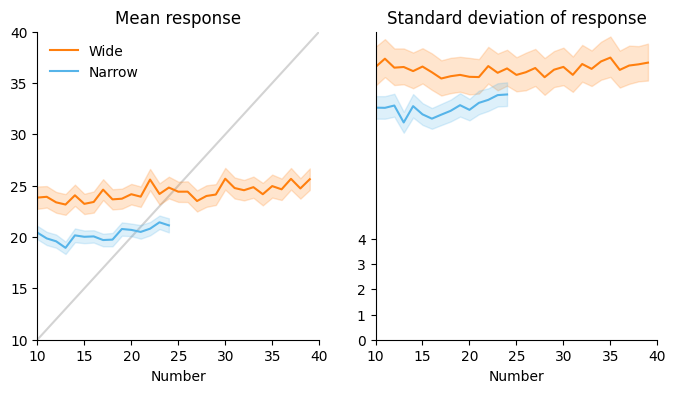

In [53]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_fmri_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary_fmri.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary_fmri.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary_fmri.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary_fmri.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_fmri_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)